## Methodology

### Systems
- **Expanse** (SDSC): HPC cluster accessed via SLURM, up to 16 cores per node
- **Linux Cluster**: Shared departmental Linux cluster, up to 8 cores

### Classifier
A Naïve Bayes classifier implemented in C, trained and evaluated using 5-fold cross-validation.
Three phases are tracked separately: **train**, **classify**, and **cv** (full cross-validation loop).

### Datasets
All runs use a synthetic diabetes dataset scaled to four sizes:
`20k`, `100k`, `500k`, and `1m` records.
A real-world heart disease dataset is included for correctness verification only.

### Parallelism Strategies
| Strategy | Description |
|----------|-------------|
| Serial   | Single-threaded baseline |
| OMP      | Shared-memory threading via OpenMP |
| MPI      | Distributed-memory parallelism via MPI |
| Hybrid   | Combined MPI processes + OpenMP threads |

### Trial Structure
Each configuration at the 1m dataset size was run **5 times** and averaged to reduce noise.
Data-size scaling runs (20k–500k) were single runs used for trend analysis only.
Speedup and efficiency are computed relative to the single-threaded serial baseline on each system.

In [2]:
from google.colab import files
import re
import pandas as pd

def parse_results_file(path):
    """
    Parse a results text file into a dict of DataFrames:
      out['serial']        — serial runs across dataset sizes
      out['omp']           — OMP thread scaling
      out['mpi']           — MPI proc scaling
      out['hybrid']        — all hybrid rows combined (procs + threads columns added)
      out['scaling']       — data-size scaling table (long format)
    """
    with open(path) as f:
        text = f.read()

    cols = ["train", "classify", "cv", "total", "speedup", "efficiency"]
    sections = re.split(r"\n{2,}", text.strip())

    serial_rows, omp_rows, mpi_rows, hybrid_rows, scaling_rows = [], [], [], [], []
    current_section = None
    current_hybrid_procs = None

    def parse_data_row(line, extra_cols):
        parts = line.split()
        nums = []
        for p in reversed(parts):
            try:
                nums.insert(0, float(p.rstrip("%")))
            except ValueError:
                break
        config_parts = parts[: len(parts) - len(nums)]
        return config_parts, nums

    for section in sections:
        lines = [l for l in section.strip().splitlines() if l.strip()]
        if not lines:
            continue

        header = lines[0].strip()

        if header.startswith("Serial"):
            current_section = "serial"
            current_hybrid_procs = None
        elif header.startswith("OMP"):
            current_section = "omp"
            current_hybrid_procs = None
        elif header.startswith("MPI"):
            current_section = "mpi"
            current_hybrid_procs = None
        elif header.startswith("Hybrid"):
            current_section = "hybrid"
            m = re.search(r"(\d+)\s+procs", header)
            current_hybrid_procs = int(m.group(1)) if m else None
        elif header.startswith("Data-size"):
            current_section = "scaling"
            current_hybrid_procs = None
        else:
            continue

        data_lines = [
            l for l in lines[1:]
            if not l.strip().startswith("-")
            and not l.strip().startswith("config")
            and not l.strip().startswith("binary")
            and "time (s)" not in l
        ]

        if current_section == "scaling":
            sizes = ["20k", "100k", "500k", "1m"]
            for line in data_lines:
                parts = line.split()
                nums = []
                label_parts = []
                for p in parts:
                    try:
                        nums.append(float(p.rstrip("%")))
                    except ValueError:
                        label_parts.append(p)
                binary = " ".join(label_parts)
                for i, size in enumerate(sizes):
                    if 2 * i + 1 < len(nums):
                        scaling_rows.append({
                            "binary": binary,
                            "size": size,
                            "time": nums[2 * i],
                            "pct_serial": nums[2 * i + 1],
                        })
            continue

        for line in data_lines:
            parts = line.split()
            if len(parts) < 3:
                continue

            nums = []
            for p in reversed(parts):
                try:
                    nums.insert(0, float(p))
                except ValueError:
                    break
            label_parts = parts[: len(parts) - len(nums)]
            label = " ".join(label_parts)

            row = dict(zip(cols, nums))

            if current_section == "serial":
                row["config"] = label
                serial_rows.append(row)
            elif current_section == "omp":
                row["threads"] = int(label_parts[0])
                omp_rows.append(row)
            elif current_section == "mpi":
                row["procs"] = int(label_parts[0])
                mpi_rows.append(row)
            elif current_section == "hybrid":
                m = re.match(r"(\d+)p\s*x\s*(\d+)t", label)
                if m:
                    row["procs"] = int(m.group(1))
                    row["threads"] = int(m.group(2))
                    hybrid_rows.append(row)

    return {
        "serial":  pd.DataFrame(serial_rows),
        "omp":     pd.DataFrame(omp_rows),
        "mpi":     pd.DataFrame(mpi_rows),
        "hybrid":  pd.DataFrame(hybrid_rows),
        "scaling": pd.DataFrame(scaling_rows),
    }


# ── Upload and parse Expanse file ──────────────────────────────────────────────
print("Upload your Expanse parsed .txt file")
expanse_upload = files.upload()
expanse_filename = list(expanse_upload.keys())[0]
expanse = parse_results_file(expanse_filename)
print(f"Loaded Expanse data from: {expanse_filename}")

# ── Upload and parse Cluster file ─────────────────────────────────────────────
print("\nUpload your Cluster parsed .txt file")
cluster_upload = files.upload()
cluster_filename = list(cluster_upload.keys())[0]
cluster = parse_results_file(cluster_filename)
print(f"Loaded Cluster data from: {cluster_filename}")

# ── Sanity check ───────────────────────────────────────────────────────────────
for name, data in [("Expanse", expanse), ("Cluster", cluster)]:
    print(f"\n── {name} ──")
    for key, df in data.items():
        print(f"  {key:8s}  {df.shape[0]} rows × {df.shape[1]} cols"
              f"    cols: {list(df.columns)}")

Upload your Expanse parsed .txt file


Saving expanse_out_v2_parsed.txt to expanse_out_v2_parsed.txt
Loaded Expanse data from: expanse_out_v2_parsed.txt

Upload your Cluster parsed .txt file


Saving cluster_output_v2_parsed.txt to cluster_output_v2_parsed (1).txt
Loaded Cluster data from: cluster_output_v2_parsed (1).txt

── Expanse ──
  serial    5 rows × 7 cols    cols: ['train', 'classify', 'cv', 'total', 'speedup', 'efficiency', 'config']
  omp       5 rows × 7 cols    cols: ['train', 'classify', 'cv', 'total', 'speedup', 'efficiency', 'threads']
  mpi       5 rows × 7 cols    cols: ['train', 'classify', 'cv', 'total', 'speedup', 'efficiency', 'procs']
  hybrid    25 rows × 8 cols    cols: ['train', 'classify', 'cv', 'total', 'speedup', 'efficiency', 'procs', 'threads']
  scaling   16 rows × 4 cols    cols: ['binary', 'size', 'time', 'pct_serial']

── Cluster ──
  serial    5 rows × 7 cols    cols: ['train', 'classify', 'cv', 'total', 'speedup', 'efficiency', 'config']
  omp       4 rows × 7 cols    cols: ['train', 'classify', 'cv', 'total', 'speedup', 'efficiency', 'threads']
  mpi       4 rows × 7 cols    cols: ['train', 'classify', 'cv', 'total', 'speedup', 'efficien

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Color palette ──────────────────────────────────────────────────────────────
# One color per concept, used consistently across all charts
COLORS = {
    "serial":       "#888780",   # gray
    "omp":          "#185FA5",   # blue
    "mpi":          "#D85A30",   # coral
    "hybrid":       "#1D9E75",   # teal
    "expanse":      "#185FA5",   # blue  (when system is the distinction)
    "cluster":      "#D85A30",   # coral
    "ideal":        "#cccccc",   # light gray dashed reference line
}

# ── Global matplotlib style ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":         150,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.color":         "#e0e0e0",
    "grid.linewidth":     0.6,
    "axes.labelsize":     11,
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "legend.frameon":     False,
    "lines.linewidth":    2.0,
    "lines.markersize":   7,
})

# ── Shared helper: save + show ─────────────────────────────────────────────────
def finish(fig, filename=None):
    """Tighten layout, optionally save, then show."""
    fig.tight_layout()
    if filename:
        fig.savefig(filename, bbox_inches="tight")
        print(f"Saved: {filename}")
    plt.show()

print("Theme loaded.")

Theme loaded.


Saved: chart1_omp_speedup.png


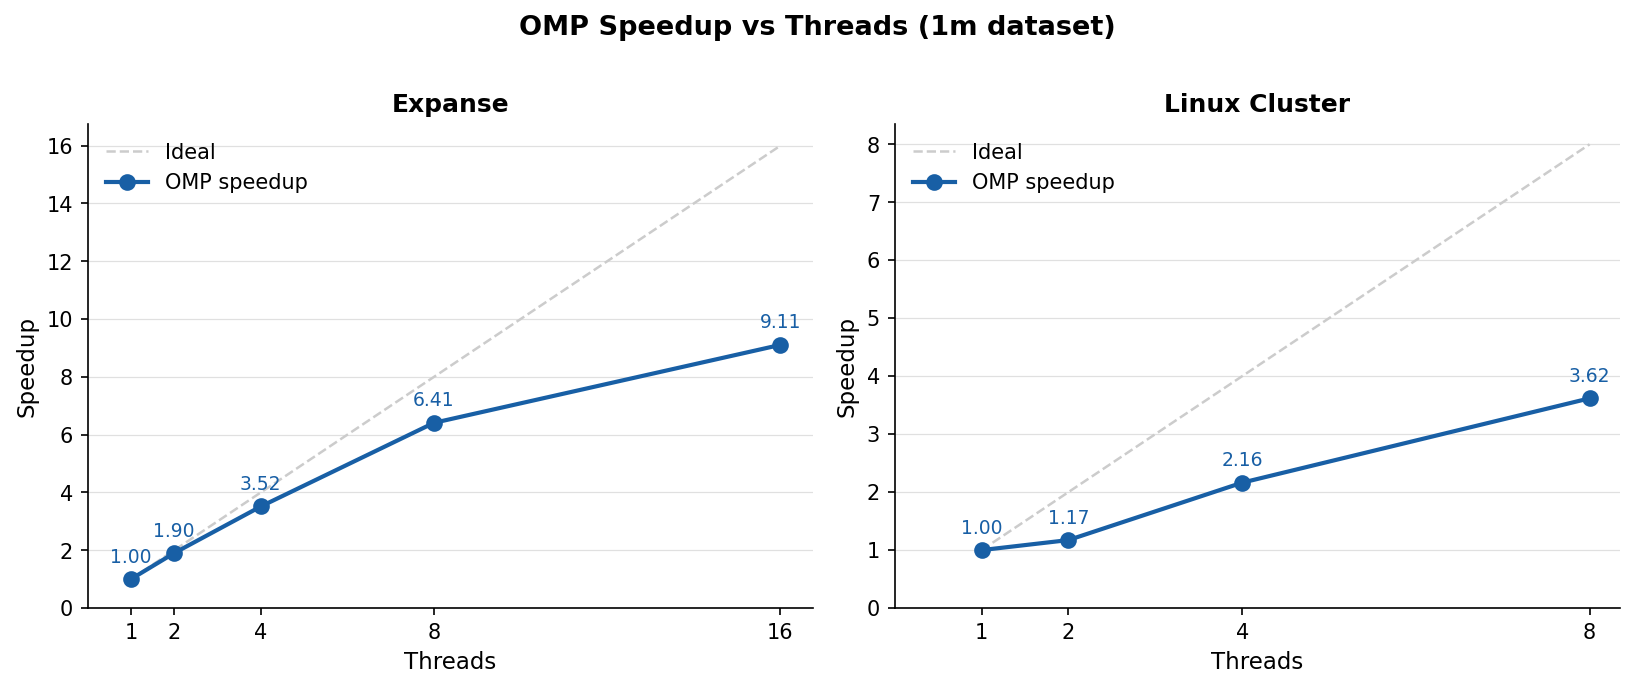

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)

datasets = [
    (expanse["omp"], "threads", "Expanse"),
    (cluster["omp"],  "threads", "Linux Cluster"),
]

for ax, (df, xcol, title) in zip(axes, datasets):
    x = df[xcol]
    ideal = x  # ideal speedup = N threads

    ax.plot(x, ideal, color=COLORS["ideal"], linewidth=1.2,
            linestyle="--", label="Ideal")
    ax.plot(x, df["speedup"], color=COLORS["omp"], marker="o",
            label="OMP speedup")

    # Annotate each point with its speedup value
    for xi, yi in zip(x, df["speedup"]):
        ax.annotate(f"{yi:.2f}", xy=(xi, yi),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=9, color=COLORS["omp"])

    ax.set_title(title)
    ax.set_xlabel("Threads")
    ax.set_ylabel("Speedup")
    ax.set_xticks(x)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.legend()

fig.suptitle("OMP Speedup vs Threads (1m dataset)", fontsize=13, fontweight="bold", y=1.01)
finish(fig, "chart1_omp_speedup.png")

Saved: chart2_mpi_speedup.png


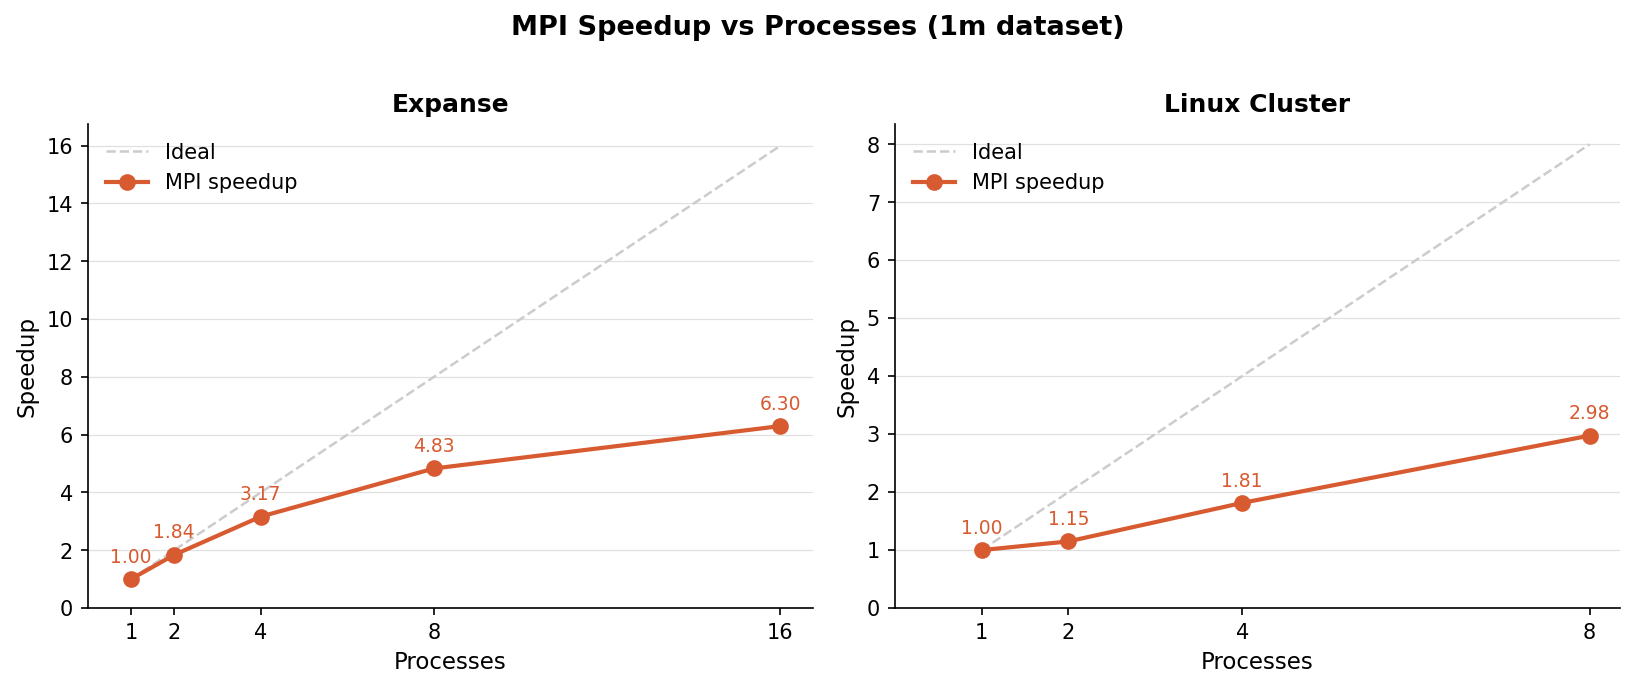

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)

datasets = [
    (expanse["mpi"], "procs", "Expanse"),
    (cluster["mpi"],  "procs", "Linux Cluster"),
]

for ax, (df, xcol, title) in zip(axes, datasets):
    x = df[xcol]
    ideal = x  # ideal speedup = N procs

    ax.plot(x, ideal, color=COLORS["ideal"], linewidth=1.2,
            linestyle="--", label="Ideal")
    ax.plot(x, df["speedup"], color=COLORS["mpi"], marker="o",
            label="MPI speedup")

    # Annotate each point
    for xi, yi in zip(x, df["speedup"]):
        ax.annotate(f"{yi:.2f}", xy=(xi, yi),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=9, color=COLORS["mpi"])

    ax.set_title(title)
    ax.set_xlabel("Processes")
    ax.set_ylabel("Speedup")
    ax.set_xticks(x)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.legend()

fig.suptitle("MPI Speedup vs Processes (1m dataset)", fontsize=13, fontweight="bold", y=1.01)
finish(fig, "chart2_mpi_speedup.png")

Saved: chart3_efficiency.png


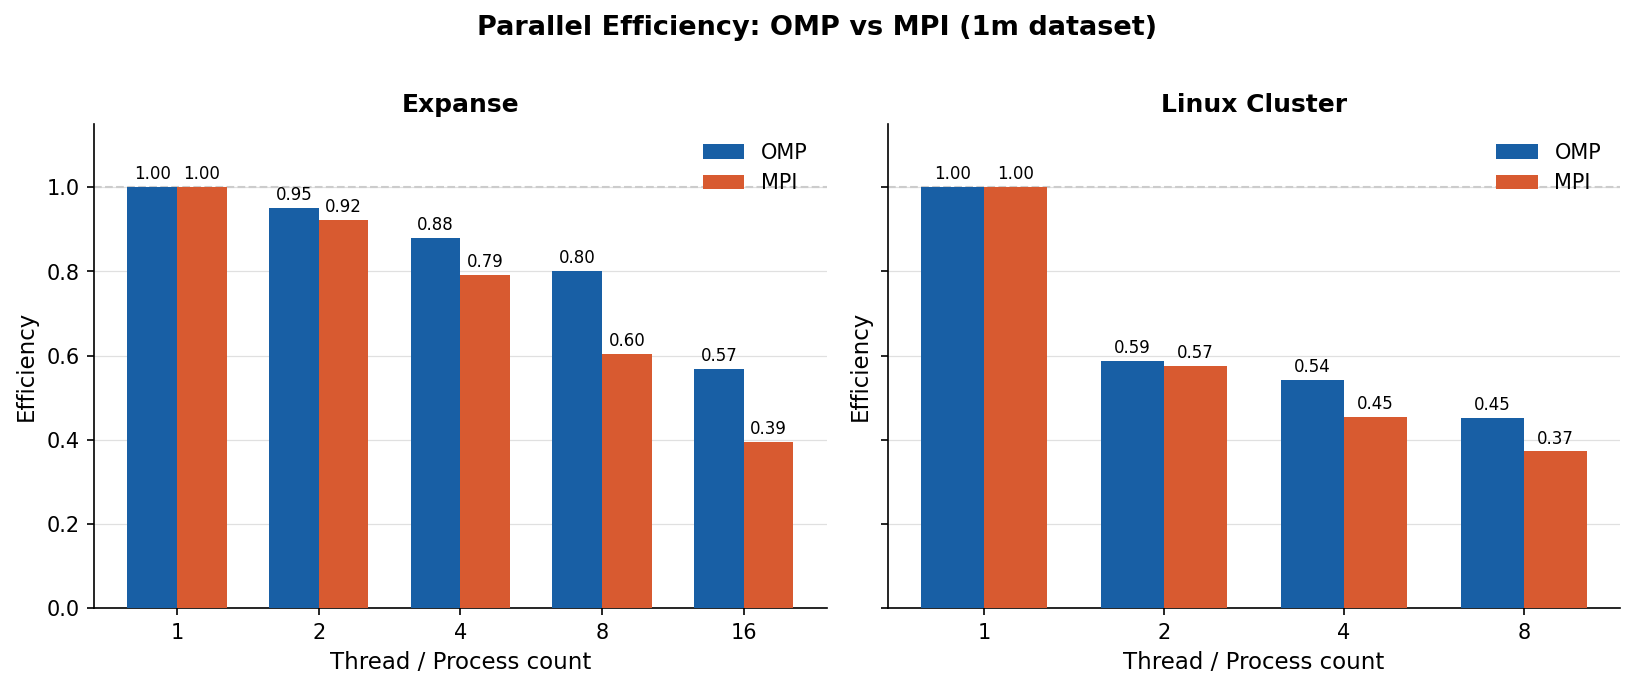

In [6]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

datasets = [
    (expanse["omp"], expanse["mpi"], "Expanse"),
    (cluster["omp"],  cluster["mpi"],  "Linux Cluster"),
]

bar_width = 0.35

for ax, (omp_df, mpi_df, title) in zip(axes, datasets):
    # Use thread/proc counts as x positions — OMP and MPI may differ in length
    omp_x = np.arange(len(omp_df))
    mpi_x = np.arange(len(mpi_df))

    omp_bars = ax.bar(omp_x - bar_width / 2, omp_df["efficiency"],
                      width=bar_width, color=COLORS["omp"],
                      label="OMP", zorder=3)
    mpi_bars = ax.bar(mpi_x + bar_width / 2, mpi_df["efficiency"],
                      width=bar_width, color=COLORS["mpi"],
                      label="MPI", zorder=3)

    # Label bars with efficiency value
    for bar in list(omp_bars) + list(mpi_bars):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=8)

    # X tick labels: use OMP thread counts (longer of the two)
    ref_df = omp_df if len(omp_df) >= len(mpi_df) else mpi_df
    ax.set_xticks(np.arange(len(ref_df)))
    ax.set_xticklabels(ref_df["threads"].astype(str) if "threads" in ref_df.columns
                       else ref_df["procs"].astype(str))
    ax.set_xlabel("Thread / Process count")
    ax.set_ylabel("Efficiency")
    ax.set_title(title)
    ax.set_ylim(0, 1.15)
    ax.axhline(1.0, color=COLORS["ideal"], linewidth=1.0, linestyle="--")
    ax.legend()

fig.suptitle("Parallel Efficiency: OMP vs MPI (1m dataset)", fontsize=13, fontweight="bold", y=1.01)
finish(fig, "chart3_efficiency.png")

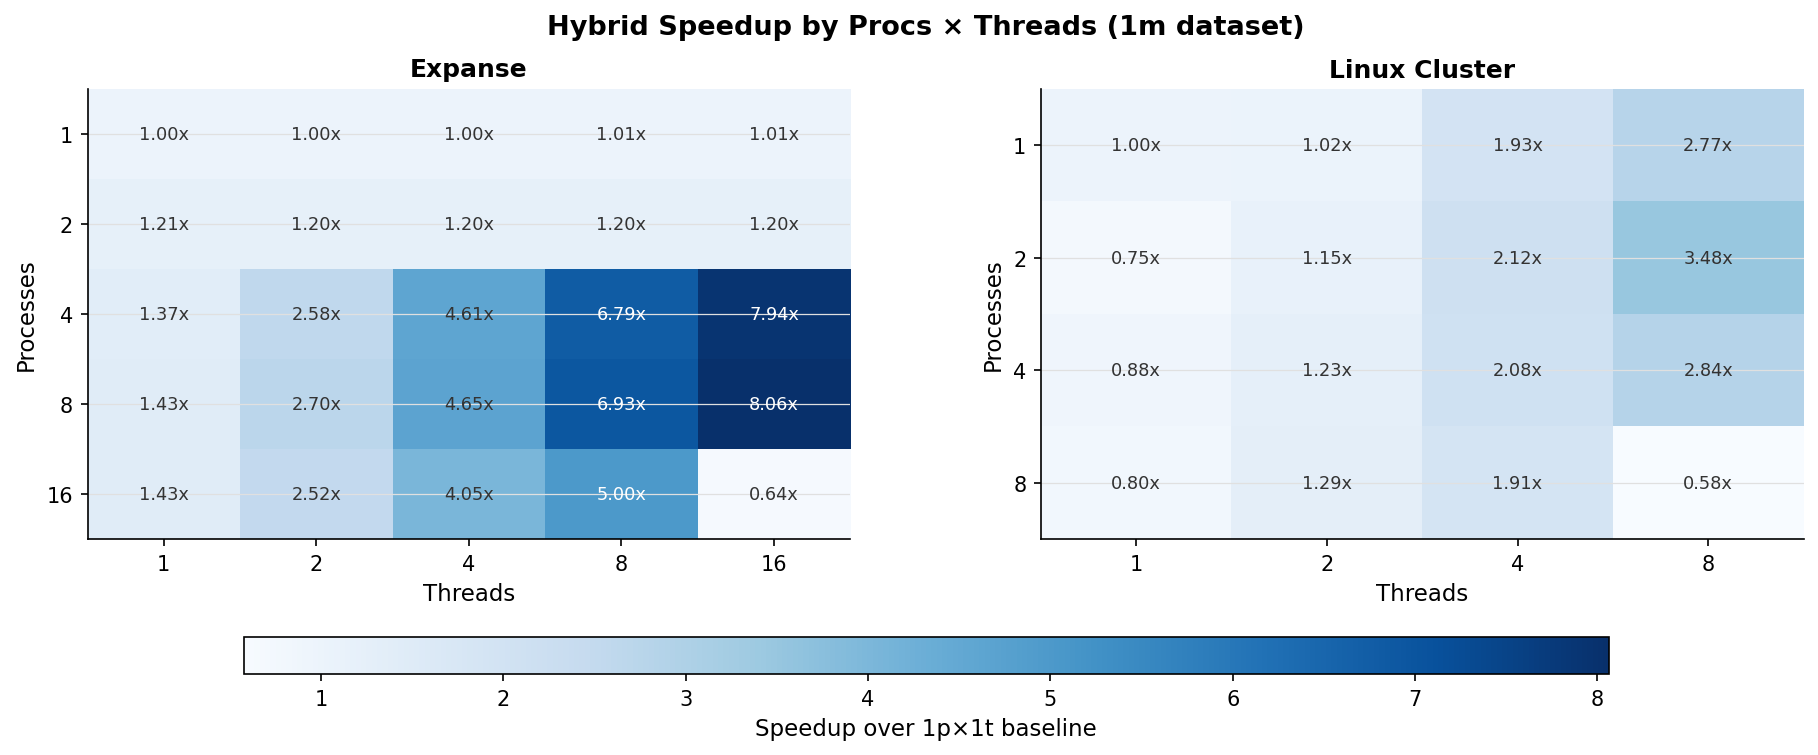

In [13]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

datasets = [
    (expanse["hybrid"], "Expanse"),
    (cluster["hybrid"], "Linux Cluster"),
]

all_vals = pd.concat([expanse["hybrid"], cluster["hybrid"]])["speedup"]
vmin, vmax = all_vals.min(), all_vals.max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

for ax, (df, title) in zip(axes, datasets):
    pivot = df.pivot(index="procs", columns="threads", values="speedup")

    im = ax.imshow(pivot.values, aspect="auto", cmap="Blues", norm=norm)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Threads")
    ax.set_ylabel("Processes")
    ax.set_title(title)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not pd.isna(val):
                ax.text(j, i, f"{val:.2f}x", ha="center", va="center",
                        fontsize=8.5,
                        color="white" if val > vmax * 0.6 else "#333333")

fig.suptitle("Hybrid Speedup by Procs × Threads (1m dataset)",
             fontsize=13, fontweight="bold")

# Manually adjust layout — do NOT call tight_layout() as it overrides these
fig.subplots_adjust(left=0.07, right=0.95, top=0.88, bottom=0.28, wspace=0.25)
cbar_ax = fig.add_axes([0.15, 0.10, 0.7, 0.05])
fig.colorbar(im, cax=cbar_ax, orientation="horizontal",
             label="Speedup over 1p×1t baseline")

fig.savefig("chart4_hybrid_heatmap.png", bbox_inches="tight")
plt.show()

Saved: chart5_scaling.png


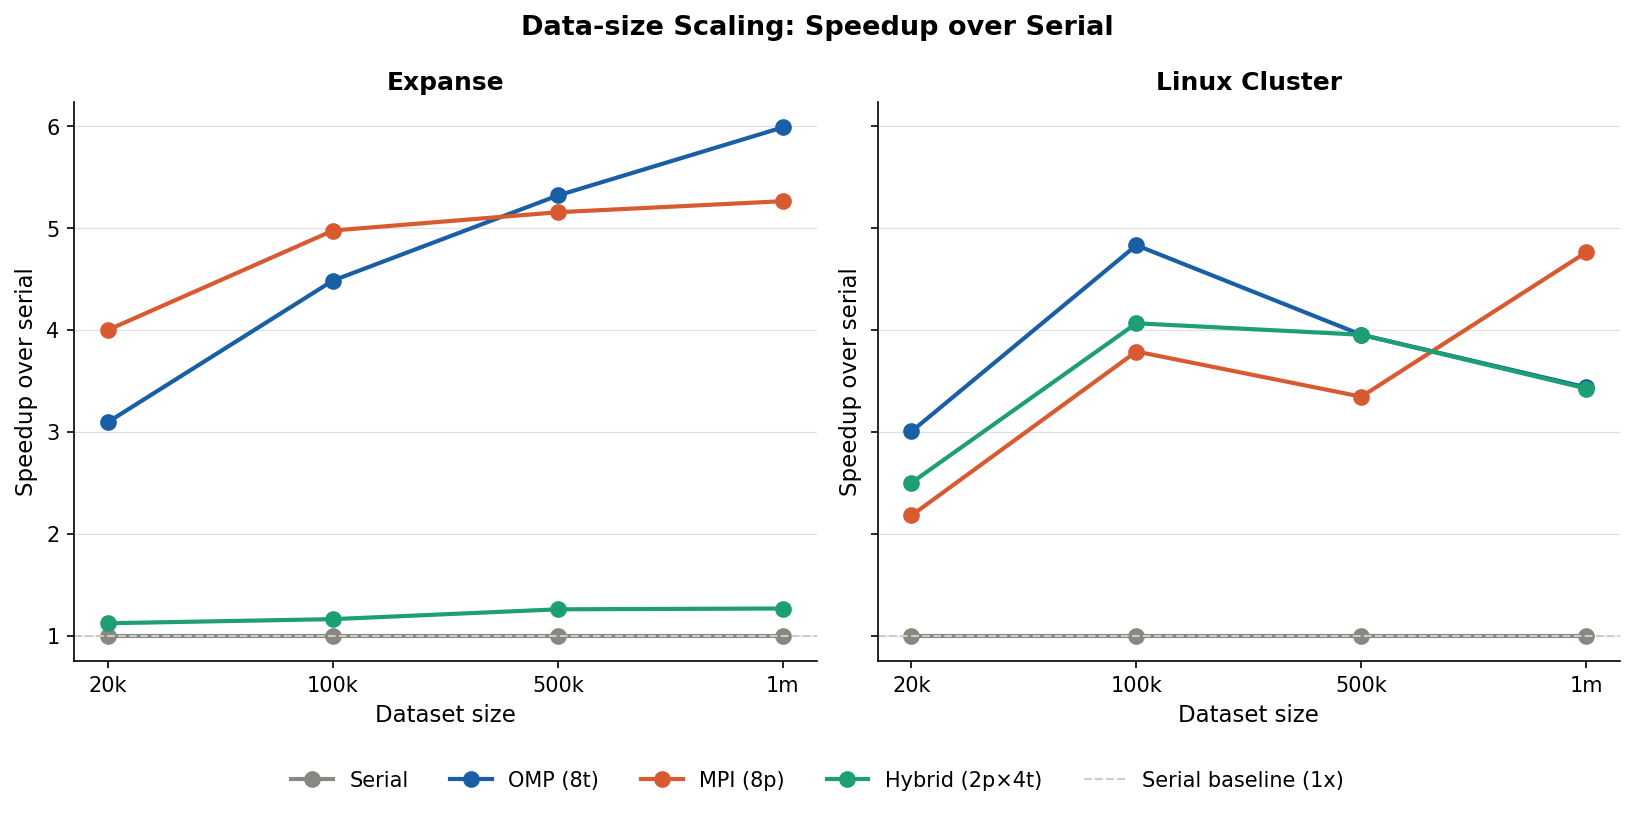

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.0), sharey=True)

datasets = [
    (expanse["scaling"], "Expanse"),
    (cluster["scaling"], "Linux Cluster"),
]

binary_styles = {
    "serial (1t)":      {"color": COLORS["serial"],  "marker": "o", "label": "Serial"},
    "omp (8t)":         {"color": COLORS["omp"],     "marker": "o", "label": "OMP (8t)"},
    "mpi (8p)":         {"color": COLORS["mpi"],     "marker": "o", "label": "MPI (8p)"},
    "hybrid (2p x 4t)": {"color": COLORS["hybrid"],  "marker": "o", "label": "Hybrid (2p×4t)"},
}

size_order = ["20k", "100k", "500k", "1m"]
x = range(len(size_order))
legend_handles = []

for ax, (df, title) in zip(axes, datasets):
    for binary, style in binary_styles.items():
        subset = df[df["binary"] == binary].set_index("size")
        y = [100 / subset.loc[s, "pct_serial"] if s in subset.index else None
             for s in size_order]
        line, = ax.plot(x, y, color=style["color"], marker=style["marker"],
                        label=style["label"])
        if ax is axes[0]:
            legend_handles.append(line)

    baseline = ax.axhline(1.0, color=COLORS["ideal"], linewidth=1.0,
                          linestyle="--", label="Serial baseline (1x)")
    if ax is axes[0]:
        legend_handles.append(baseline)

    ax.set_xticks(x)
    ax.set_xticklabels(size_order)
    ax.set_xlabel("Dataset size")
    ax.set_ylabel("Speedup over serial")
    ax.set_title(title)

fig.suptitle("Data-size Scaling: Speedup over Serial", fontsize=13, fontweight="bold")
fig.legend(handles=legend_handles, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.08), frameon=False)
finish(fig, "chart5_scaling.png")

Saved: chart6_phase_breakdown.png


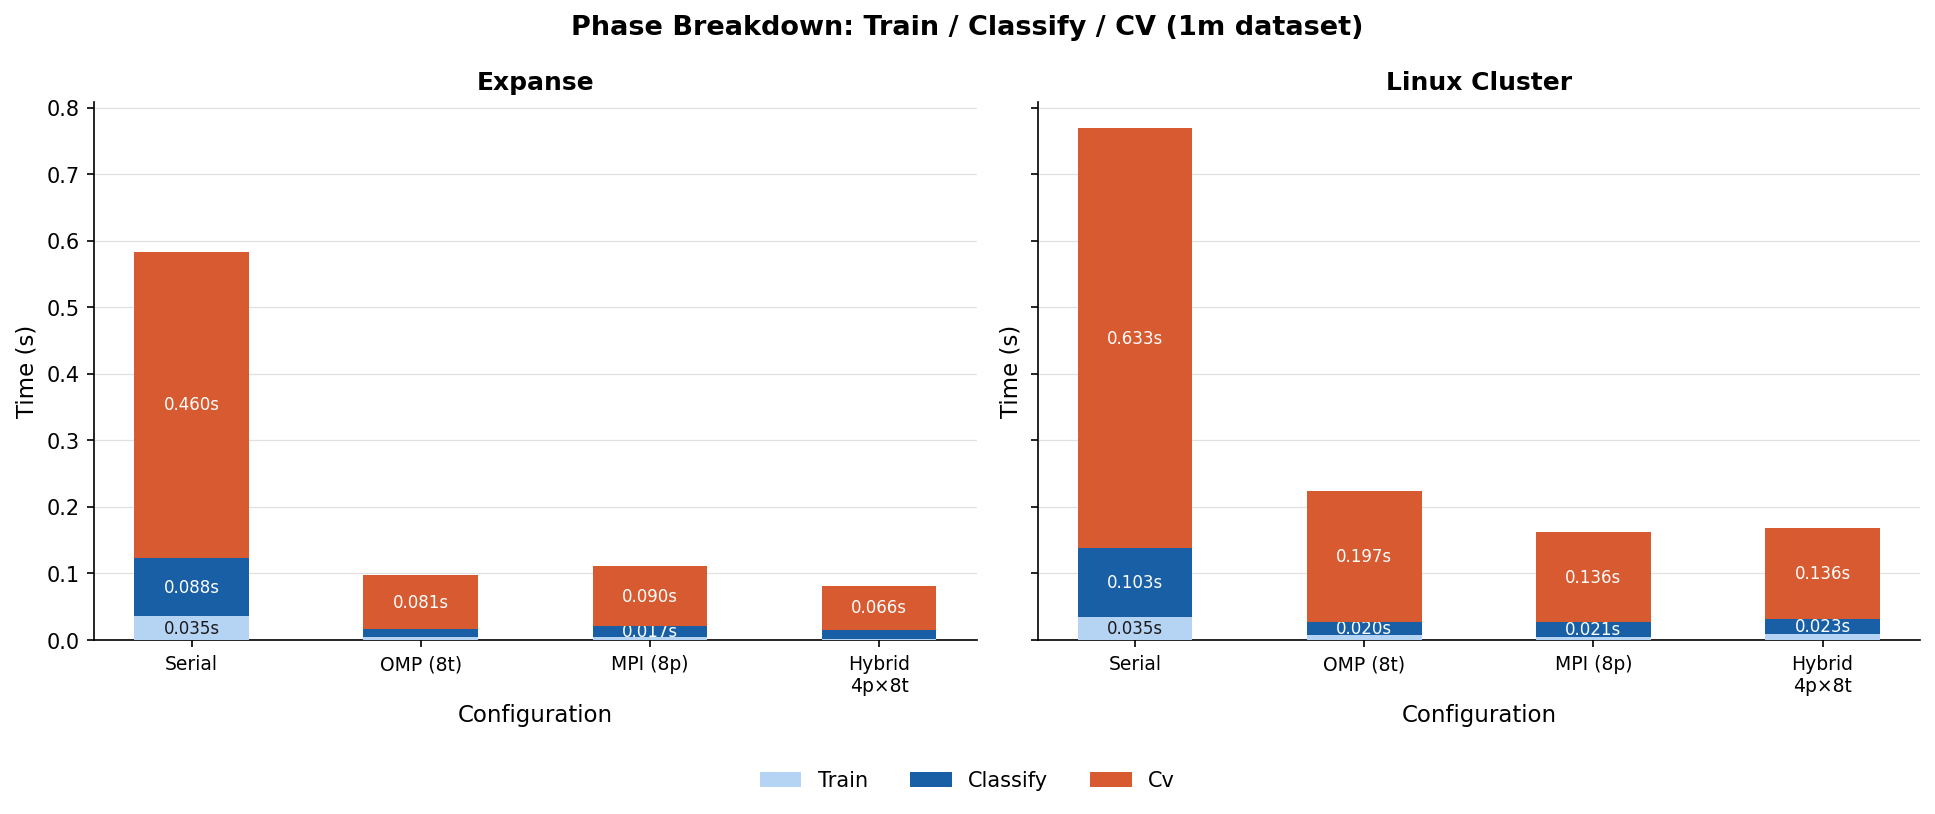

In [8]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0), sharey=True)

# Pick the most interesting configs to compare across both systems
configs = {
    "Serial":         lambda d: d["serial"][d["serial"]["config"] == "1m"].iloc[0],
    "OMP (8t)":       lambda d: d["omp"][d["omp"]["threads"] == 8].iloc[0],
    "MPI (8p)":       lambda d: d["mpi"][d["mpi"]["procs"] == 8].iloc[0],
    "Hybrid\n4p×8t":  lambda d: d["hybrid"][(d["hybrid"]["procs"] == 4) & (d["hybrid"]["threads"] == 8)].iloc[0],
}

phase_colors = {
    "train":    "#B5D4F4",   # light blue
    "classify": "#185FA5",   # mid blue
    "cv":       "#D85A30",   # coral — CV is the bottleneck, make it stand out
}

datasets = [
    (expanse, "Expanse"),
    (cluster, "Linux Cluster"),
]

for ax, (data, title) in zip(axes, datasets):
    labels = list(configs.keys())
    rows = []
    for label, getter in configs.items():
        try:
            rows.append(getter(data))
        except IndexError:
            rows.append(None)

    x = np.arange(len(labels))
    bar_width = 0.5
    bottoms = np.zeros(len(labels))

    for phase, color in phase_colors.items():
        heights = [r[phase] if r is not None else 0 for r in rows]
        bars = ax.bar(x, heights, bar_width, bottom=bottoms,
                      color=color, label=phase.capitalize(), zorder=3)
        # Label each segment if tall enough
        for i, (h, b) in enumerate(zip(heights, bottoms)):
            if h > 0.015:
                ax.text(x[i], b + h / 2, f"{h:.3f}s",
                        ha="center", va="center", fontsize=8,
                        color="white" if phase == "classify" or phase == "cv" else "#1a1a1a")
        bottoms += np.array(heights)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel("Configuration")
    ax.set_ylabel("Time (s)")
    ax.set_title(title)

fig.suptitle("Phase Breakdown: Train / Classify / CV (1m dataset)",
             fontsize=13, fontweight="bold")

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.08), frameon=False)

finish(fig, "chart6_phase_breakdown.png")

Saved: chart7_summary_table.png


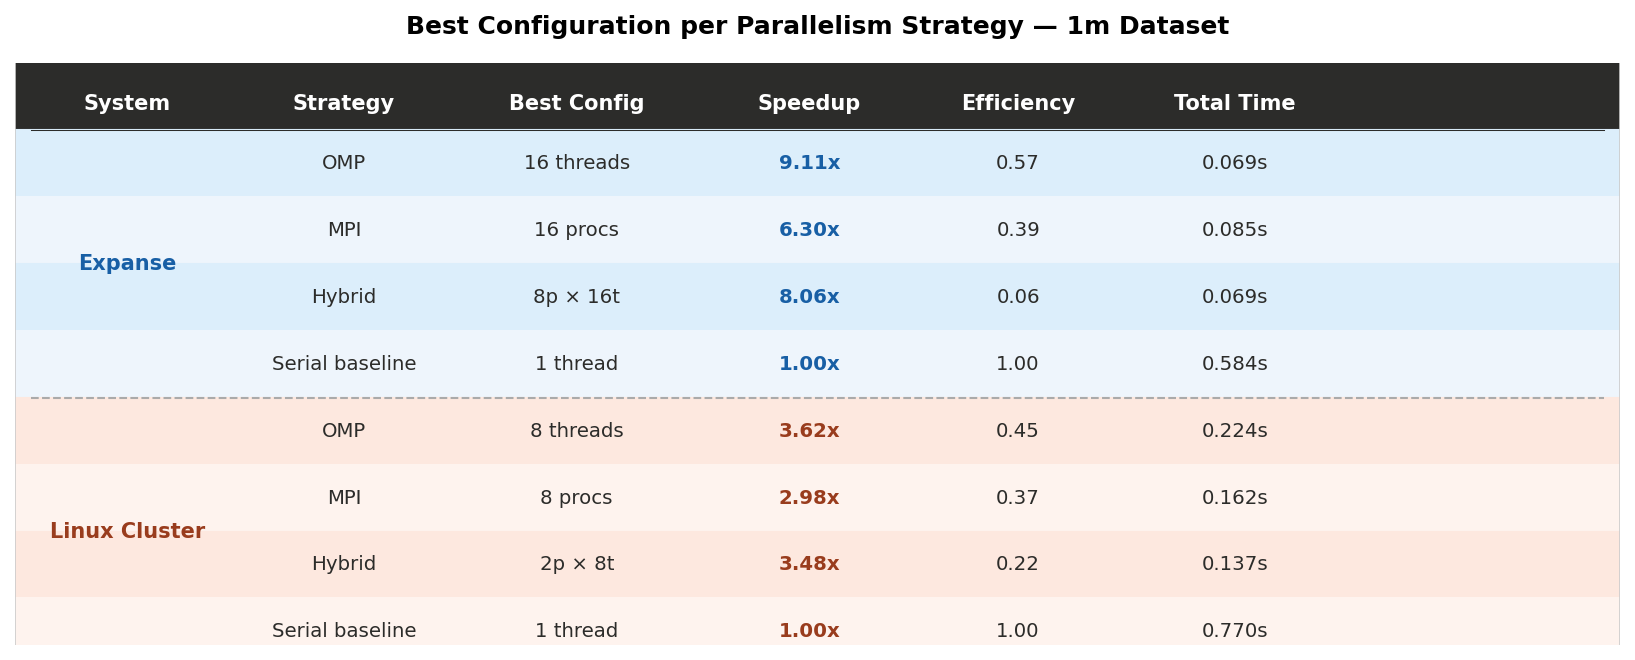

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axis("off")

def summarize(data, system_name):
    rows = []
    omp = data["omp"].loc[data["omp"]["speedup"].idxmax()]
    rows.append([system_name, "OMP",
                 f"{int(omp['threads'])} threads",
                 f"{omp['speedup']:.2f}x",
                 f"{omp['efficiency']:.2f}",
                 f"{omp['total']:.3f}s"])

    mpi = data["mpi"].loc[data["mpi"]["speedup"].idxmax()]
    rows.append([system_name, "MPI",
                 f"{int(mpi['procs'])} procs",
                 f"{mpi['speedup']:.2f}x",
                 f"{mpi['efficiency']:.2f}",
                 f"{mpi['total']:.3f}s"])

    hyb = data["hybrid"].loc[data["hybrid"]["speedup"].idxmax()]
    rows.append([system_name, "Hybrid",
                 f"{int(hyb['procs'])}p × {int(hyb['threads'])}t",
                 f"{hyb['speedup']:.2f}x",
                 f"{hyb['efficiency']:.2f}",
                 f"{hyb['total']:.3f}s"])

    serial = data["serial"][data["serial"]["config"] == "1m"].iloc[0]
    rows.append([system_name, "Serial baseline",
                 "1 thread",
                 "1.00x",
                 "1.00",
                 f"{serial['total']:.3f}s"])
    return rows

rows = summarize(expanse, "Expanse") + summarize(cluster, "Linux Cluster")
col_labels = ["System", "Strategy", "Best Config", "Speedup", "Efficiency", "Total Time"]
col_widths = [0.14, 0.13, 0.16, 0.13, 0.13, 0.14]

# System accent colors
system_colors = {
    "Expanse":       {"header": "#185FA5", "even": "#dceefb", "odd": "#eef5fc"},
    "Linux Cluster": {"header": "#993C1D", "even": "#fde8df", "odd": "#fef3ee"},
}

# Draw header row
headers = col_labels
header_bg = "#2c2c2a"
xs = [sum(col_widths[:i]) + col_widths[i] / 2 for i in range(len(col_widths))]
y_header = 0.93

for i, (label, x) in enumerate(zip(headers, xs)):
    ax.text(x, y_header, label, ha="center", va="center",
            fontsize=10, fontweight="bold", color="white",
            transform=ax.transAxes)

ax.plot([0.01, 0.99], [y_header - 0.045, y_header - 0.045],
        color="#2c2c2a", linewidth=0.5, transform=ax.transAxes)

# Fill header background
from matplotlib.patches import FancyBboxPatch
header_rect = plt.Rectangle((0, y_header - 0.045), 1, 0.115,
                              color=header_bg, transform=ax.transAxes, zorder=0)
ax.add_patch(header_rect)

# Draw data rows
row_height = 0.115
y_start = y_header - 0.045

for r, row in enumerate(rows):
    system = row[0]
    colors = system_colors[system]
    bg = colors["even"] if r % 2 == 0 else colors["odd"]

    # Row background
    rect = plt.Rectangle((0, y_start - (r + 1) * row_height),
                          1, row_height,
                          color=bg, transform=ax.transAxes, zorder=0)
    ax.add_patch(rect)

    # System label — only on first row of each system block
    is_first_of_system = (r == 0 or rows[r - 1][0] != system)
    system_count = sum(1 for rw in rows if rw[0] == system)
    system_start_r = next(i for i, rw in enumerate(rows) if rw[0] == system)

    for c, (val, x) in enumerate(zip(row, xs)):
        if c == 0:
            if is_first_of_system:
                # Draw system name centered across its block
                mid_y = y_start - (system_start_r + system_count / 2) * row_height
                ax.text(x, mid_y, val, ha="center", va="center",
                        fontsize=10, fontweight="bold",
                        color=colors["header"],
                        transform=ax.transAxes)
        else:
            weight = "bold" if c == 3 else "normal"  # bold speedup
            color  = colors["header"] if c == 3 else "#2c2c2a"
            ax.text(x, y_start - (r + 0.5) * row_height, val,
                    ha="center", va="center",
                    fontsize=9.5, fontweight=weight, color=color,
                    transform=ax.transAxes)

# Divider between systems
ax.plot([0.01, 0.99], [y_start - 4 * row_height, y_start - 4 * row_height],
        color="#aaaaaa", linewidth=1.0, linestyle="--", transform=ax.transAxes)

# Outer border
border = plt.Rectangle((0, y_start - len(rows) * row_height),
                        1, y_header - y_start + 0.16 + len(rows) * row_height,
                        fill=False, edgecolor="#cccccc", linewidth=0.8,
                        transform=ax.transAxes)
ax.add_patch(border)

ax.set_title("Best Configuration per Parallelism Strategy — 1m Dataset",
             fontsize=12, fontweight="bold", pad=14)

finish(fig, "chart7_summary_table.png")

Saved: chart2b_mpi_speedup_no_cv.png


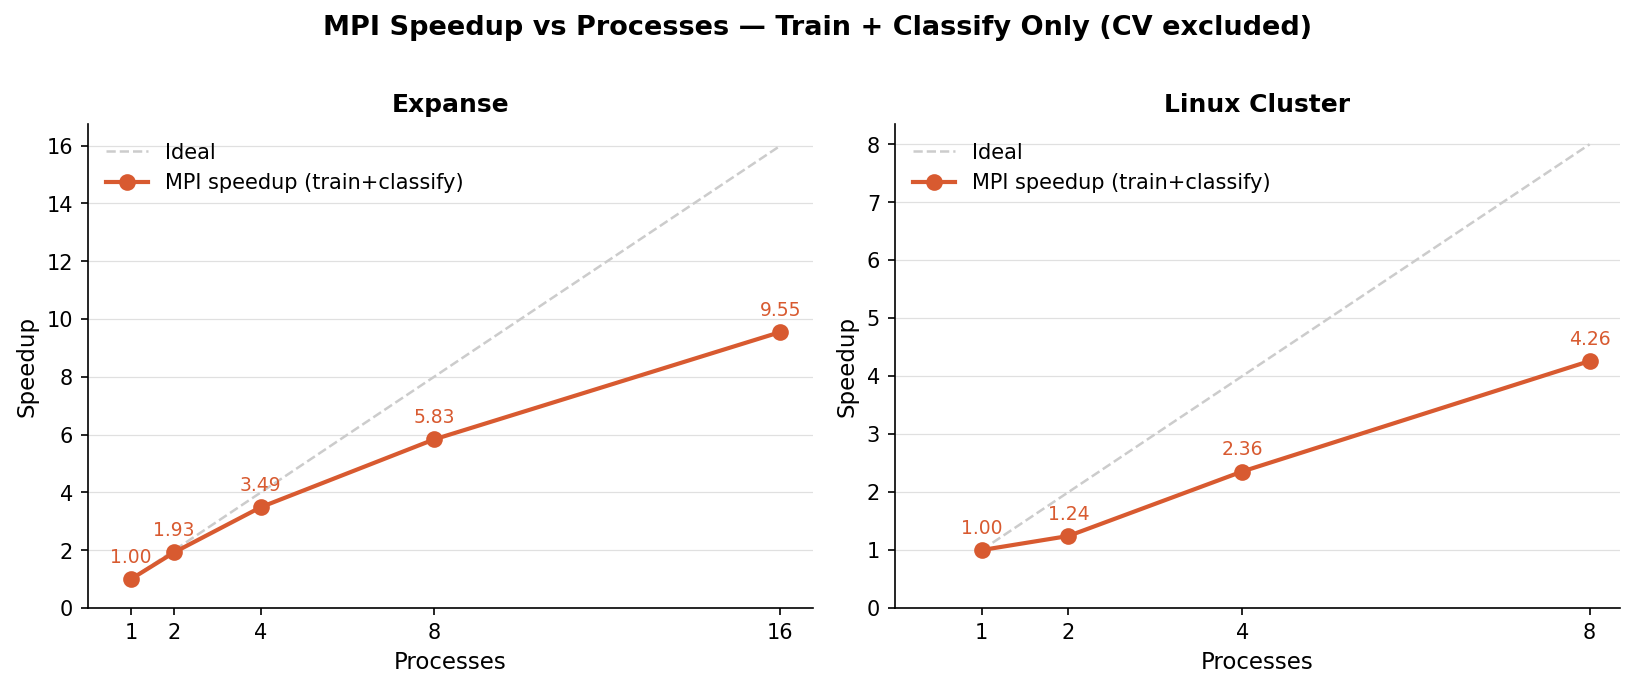

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)

datasets = [
    (expanse["mpi"], "Expanse"),
    (cluster["mpi"],  "Linux Cluster"),
]

for ax, (df, title) in zip(axes, datasets):
    df = df.copy()
    df["compute"] = df["train"] + df["classify"]
    baseline = df[df["procs"] == 1]["compute"].values[0]
    df["compute_speedup"] = baseline / df["compute"]

    x = df["procs"]
    ideal = x

    ax.plot(x, ideal, color=COLORS["ideal"], linewidth=1.2,
            linestyle="--", label="Ideal")
    ax.plot(x, df["compute_speedup"], color=COLORS["mpi"], marker="o",
            label="MPI speedup (train+classify)")

    for xi, yi in zip(x, df["compute_speedup"]):
        ax.annotate(f"{yi:.2f}", xy=(xi, yi),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=9, color=COLORS["mpi"])

    ax.set_title(title)
    ax.set_xlabel("Processes")
    ax.set_ylabel("Speedup")
    ax.set_xticks(x)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.legend()

fig.suptitle("MPI Speedup vs Processes — Train + Classify Only (CV excluded)",
             fontsize=13, fontweight="bold", y=1.01)
finish(fig, "chart2b_mpi_speedup_no_cv.png")

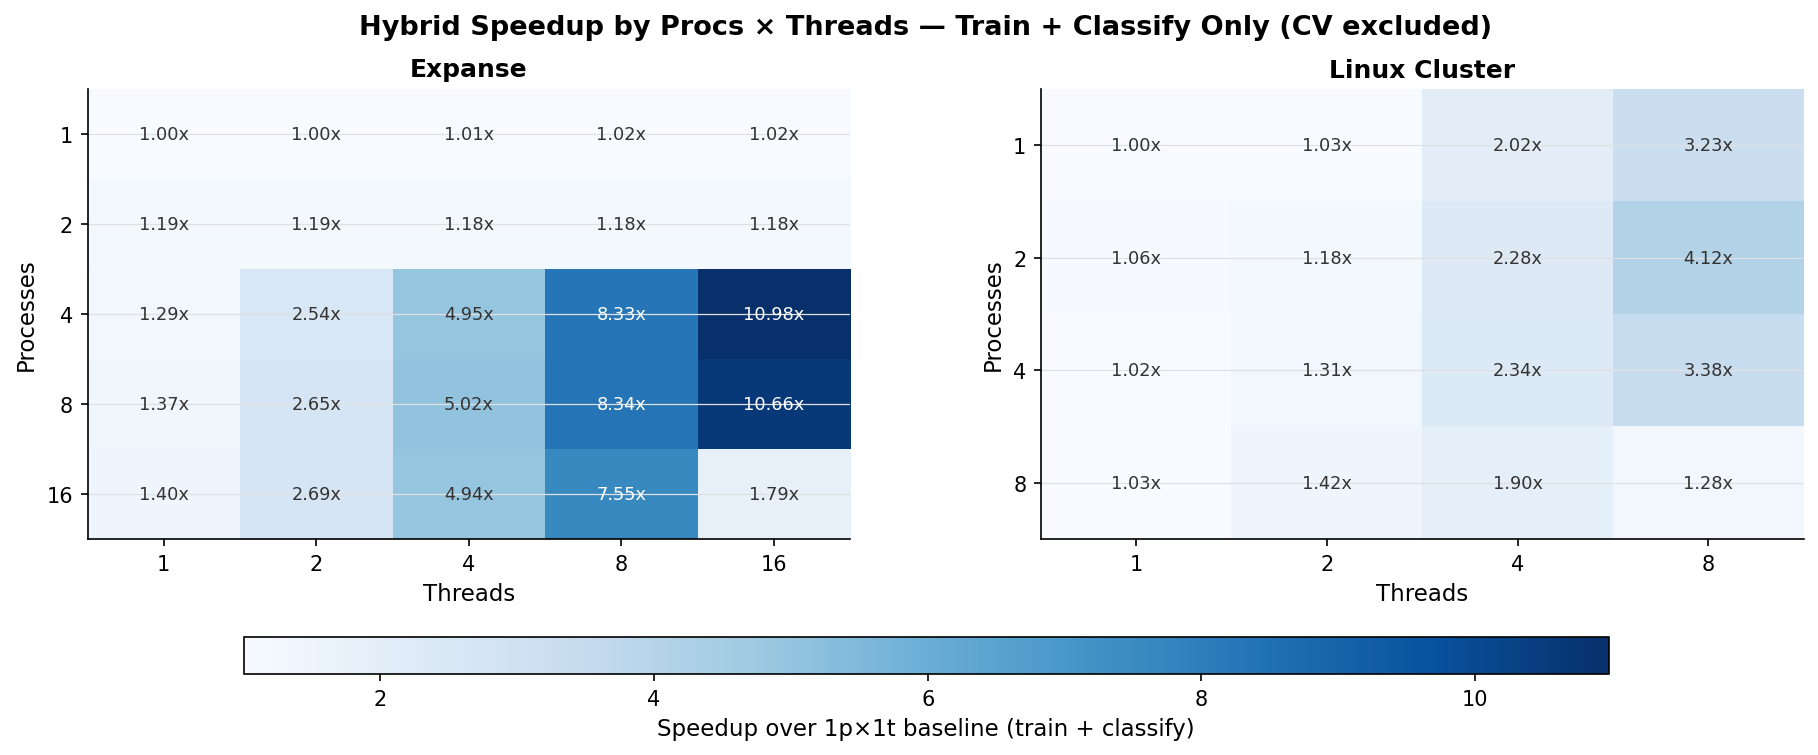

In [11]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

# Compute train+classify speedup first, then build datasets list
for data in [expanse, cluster]:
    baseline_compute = (
        data["hybrid"][(data["hybrid"]["procs"] == 1) &
                       (data["hybrid"]["threads"] == 1)].iloc[0][["train", "classify"]].sum()
    )
    data["hybrid"] = data["hybrid"].copy()
    data["hybrid"]["compute_speedup"] = baseline_compute / (
        data["hybrid"]["train"] + data["hybrid"]["classify"]
    )

# Build AFTER computation so df references the updated DataFrames
datasets = [
    (expanse["hybrid"], "Expanse"),
    (cluster["hybrid"], "Linux Cluster"),
]

all_vals = pd.concat([expanse["hybrid"], cluster["hybrid"]])["compute_speedup"]
vmin, vmax = all_vals.min(), all_vals.max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

for ax, (df, title) in zip(axes, datasets):
    pivot = df.pivot(index="procs", columns="threads", values="compute_speedup")

    im = ax.imshow(pivot.values, aspect="auto", cmap="Blues", norm=norm)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Threads")
    ax.set_ylabel("Processes")
    ax.set_title(title)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not pd.isna(val):
                ax.text(j, i, f"{val:.2f}x", ha="center", va="center",
                        fontsize=8.5,
                        color="white" if val > vmax * 0.6 else "#333333")

fig.suptitle("Hybrid Speedup by Procs × Threads — Train + Classify Only (CV excluded)",
             fontsize=13, fontweight="bold")

fig.subplots_adjust(left=0.07, right=0.95, top=0.88, bottom=0.28, wspace=0.25)
cbar_ax = fig.add_axes([0.15, 0.10, 0.7, 0.05])
fig.colorbar(im, cax=cbar_ax, orientation="horizontal",
             label="Speedup over 1p×1t baseline (train + classify)")

fig.savefig("chart4b_hybrid_heatmap_no_cv.png", bbox_inches="tight")
plt.show()